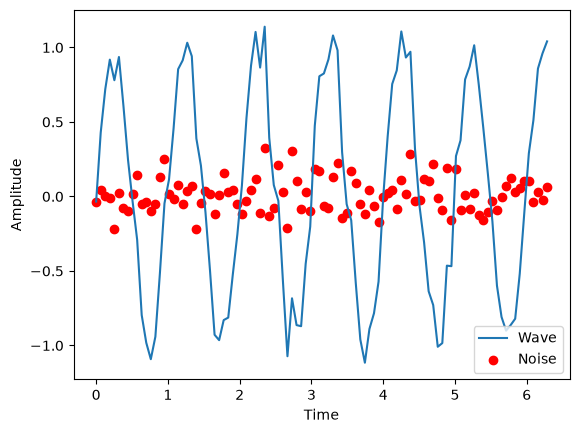

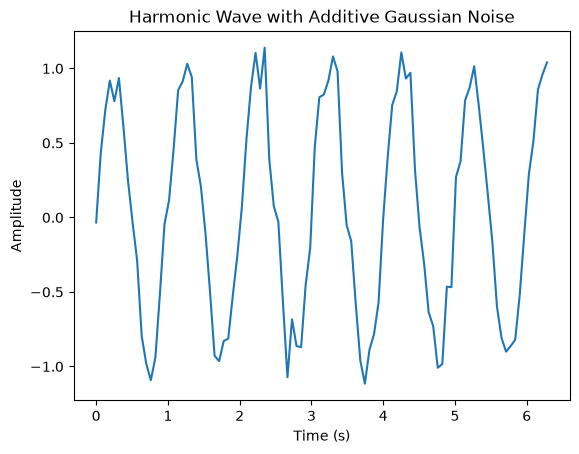

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
import random

# Generate random data for the wave
n = 100
x = np.linspace(0, 2*np.pi, n)
y = np.sin(x) + np.random.randn(n) * 0.5  # Adding noise to make the crests and troughs more curvy
y = np.sin(2*np.pi*x)
noise = np.random.normal(0, 0.1, n)
y = y + noise

# Plot the wave and the noise
fig, ax = plt.subplots()
ax.plot(x, y, label='Wave')
ax.scatter(x, noise, label='Noise', color='r')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.legend()
plt.show()
fig, ax = plt.subplots()
line, = ax.plot(x, y)

# Add a title and labels
plt.title('Harmonic Wave with Additive Gaussian Noise')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# Define the update function for the animation
def update(frame):
    # Generate new random data for the wave
    noise = np.random.normal(0, 0.1, n)
    y = y + noise

    # Update the wave data
    line.set_ydata(y)

    # Return the updated line
    return line

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 10, 0.01), interval=100)

# Display the animation
plt.show()

=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===
Total Data Points:  120
Injected Outliers Count:  9
Outlier Indices:  [ 65  95  26  97  21   4 103 110 117]
Clean Data Mean: 0.6443


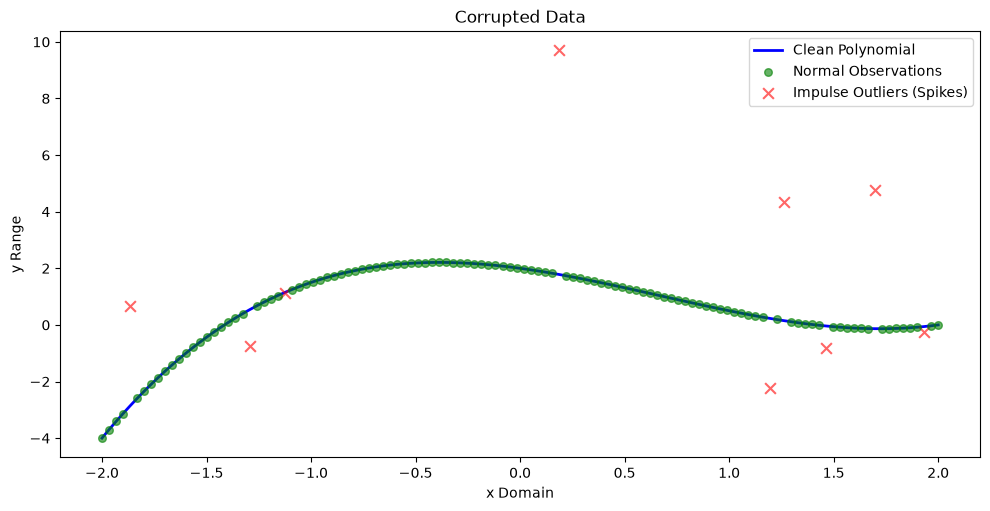

In [27]:
x_poly = np.linspace(
    start=-2.0,
    stop=2.0,
    num=120,
)

y_poly_clean = 0.5 * (x_poly ** 3) - (x_poly ** 2) - x_poly + 2
y_poly_corrupted = y_poly_clean.copy()

num_outliers = int(0.08 * len(x_poly))
outlier_indices = np.random.choice(
    a = len(x_poly),
    size=num_outliers, 
    replace=False
)

# inject random positive and negative spikes
spikes_magnitude = np.random.uniform(
    low=-4.0,
    high=8.0,
    size=num_outliers
)
y_poly_corrupted[outlier_indices] += spikes_magnitude

print("=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===")
print("Total Data Points: ", len(x_poly))
print("Injected Outliers Count: ", num_outliers)
print("Outlier Indices: ", outlier_indices)
print(f"Clean Data Mean: {y_poly_clean.mean():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(
    x_poly,
    y_poly_clean,
    label="Clean Polynomial",
    color="blue",
    linewidth = 2,
    zorder = 2
)

normal_mask = np.ones_like(x_poly, dtype=bool)
normal_mask[outlier_indices] = False

plt.scatter(
    x_poly[normal_mask],
    y_poly_corrupted[normal_mask],
    label="Normal Observations",
    color="green",
    s=30,
    zorder = 3,
    alpha = 0.6
)

plt.scatter(
    x = x_poly[outlier_indices],
    y = y_poly_corrupted[outlier_indices],
    label="Impulse Outliers (Spikes)",
    color="red",
    s=60,
    zorder = 2,
    alpha = 0.6,
    marker = 'x'
)

plt.xlabel("x Domain")
plt.ylabel("y Range")
plt.tight_layout()
plt.legend()
plt.title("Corrupted Data")
plt.show()

### Multi-Component Composite Signal + Heteroscedastic Noise
#### Overview and Purpose

In this section, we will explore the multi-component composite signal + heteroscedastic noise model. This model is a combination of a multi-component composite signal and heteroscedastic noise. The multi-component composite signal is a combination of multiple signals, while the heteroscedastic noise is a random variable that has a different variance for each observation.

#### Mathematical Formula

$$y_t = \sum_{i=1}^{K} \alpha_i \phi_i(t) + \epsilon_t,$$
where $y_t$ is the observed signal at time $t$, $K$ is the number of components, $\alpha_i$ is the weight of the $i$-th component, $\phi_i(t)$ is the $i$-th component of the multi-component composite signal, and $\epsilon_t$ is the heteroscedastic noise at time $t$ with a different variance for each observation.

#### Pronounciation and Symbol Guide

$$
\begin{aligned}
&y_t \quad \text{is pronounced as } y \text{ sub } t \\
&\sum_{i=1}^{K} \quad \text{is pronounced as } \text{the sum from } i = 1 \text{ to } K \\
&\alpha_i \quad \text{is pronounced as } \alpha \text{ sub } i \\
&\phi_i(t) \quad \text{is pronounced as } \phi \text{ sub } i \text{ of } t \\
&\epsilon_t \quad \text{is pronounced as } \epsilon \text{ sub } t \\
&K \quad \text{is pronounced as } K \\
&t \quad \text{is pronounced as } t \\
&\text{heteroscedastic noise} \quad \text{is pronounced as } \text{heteroscedastic noise}
\end{aligned}
$$